In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("stock.csv")
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-03-20 00:00:00-04:00,386.899994,397.820007,385.799988,389.609985,4003800,0.0,0.0,adobe,ADBE,technology,usa,NaN
1,2025-03-20 00:00:00-04:00,131.100006,132.289993,130.210007,130.509995,378500,0.0,0.0,lvmh,LVMUY,luxury goods,france,NaN
2,2025-03-20 00:00:00-04:00,236.559998,241.759995,236.199997,239.009995,8321600,0.0,0.0,jpmorgan chase & co,JPM,finance,usa,NaN
3,2025-03-20 00:00:00-04:00,60.480000,61.020000,60.340000,60.619999,16503100,0.0,0.0,cisco,CSCO,technology,usa,NaN
4,2025-03-20 00:00:00-04:00,59.020000,59.290001,58.689999,59.230000,2840400,0.0,0.0,unilever,UL,consumer goods,netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305209,2000-01-03 00:00:00-05:00,13.822670,13.822670,13.675379,13.720699,48000,0.0,0.0,honda,HMC,automotive,japan,NaN
305210,2000-01-03 00:00:00-05:00,3.990652,4.061914,3.848129,3.990652,134500,0.0,0.0,nintendo,NTDOY,gaming,japan,NaN
305211,2000-01-03 00:00:00-05:00,31.512873,31.512873,30.431443,30.799129,6057400,0.0,0.0,costco,COST,retail,usa,NaN
305212,2000-01-03 00:00:00-05:00,38.147537,38.255972,35.935457,37.496925,53076000,0.0,0.0,cisco,CSCO,technology,usa,NaN


In [4]:
df.dtypes

Date              object
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Dividends        float64
Stock Splits     float64
Brand_Name        object
Ticker            object
Industry_Tag      object
Country           object
Capital Gains    float64
dtype: object

In [10]:
df['Date'] = pd.to_datetime(df['Date'],utc = True)
df['Year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

In [11]:
df.dtypes

Date             datetime64[ns, UTC]
Open                         float64
High                         float64
Low                          float64
Close                        float64
Volume                         int64
Dividends                    float64
Stock Splits                 float64
Brand_Name                    object
Ticker                        object
Industry_Tag                  object
Country                       object
Capital Gains                float64
Year                           int32
month                          int32
dtype: object

In [13]:
aapl_df = df[(df['Ticker'] == 'AAPL') & (df['Year'] >= 2020) & (df['Year'] <=  2025)].sort_values('Date')
aapl_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains,Year,month
81652,2020-01-02 05:00:00+00:00,72.246685,73.310001,71.990615,73.249031,135480400,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81624,2020-01-03 05:00:00+00:00,72.468602,73.305105,72.310083,72.536888,146322800,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81564,2020-01-06 05:00:00+00:00,71.649176,73.153905,71.395540,73.114883,118387200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81486,2020-01-07 05:00:00+00:00,73.124639,73.383150,72.549088,72.771019,108872000,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81431,2020-01-08 05:00:00+00:00,72.471053,74.246491,72.471053,73.941643,132079200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1


In [14]:
aapl_df['MA_50'] = aapl_df['Close'].rolling(window=50).mean()

In [15]:
aapl_df['MA_200'] = aapl_df['Close'].rolling(window=200).mean()

In [18]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains,Year,month
0,2025-03-20 04:00:00+00:00,386.899994,397.820007,385.799988,389.609985,4003800,0.0,0.0,adobe,ADBE,technology,usa,NaN,2025,3
1,2025-03-20 04:00:00+00:00,131.100006,132.289993,130.210007,130.509995,378500,0.0,0.0,lvmh,LVMUY,luxury goods,france,NaN,2025,3
2,2025-03-20 04:00:00+00:00,236.559998,241.759995,236.199997,239.009995,8321600,0.0,0.0,jpmorgan chase & co,JPM,finance,usa,NaN,2025,3
3,2025-03-20 04:00:00+00:00,60.480000,61.020000,60.340000,60.619999,16503100,0.0,0.0,cisco,CSCO,technology,usa,NaN,2025,3
4,2025-03-20 04:00:00+00:00,59.020000,59.290001,58.689999,59.230000,2840400,0.0,0.0,unilever,UL,consumer goods,netherlands,NaN,2025,3


In [21]:
import plotly.graph_objects as go

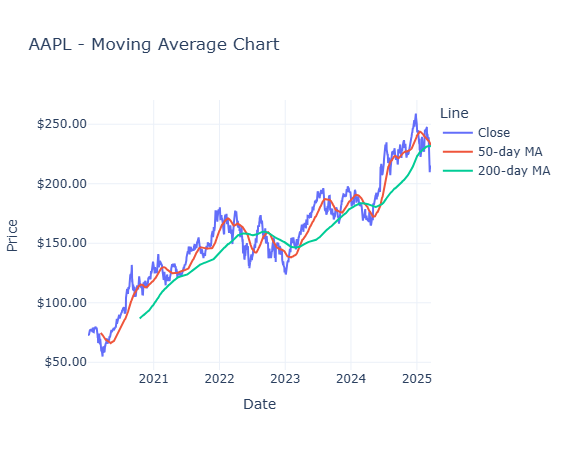

In [24]:
# Create plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=aapl_df['Date'], y=aapl_df['Close'], mode='lines', name='Close'))
fig.add_trace(go.Scatter(x=aapl_df['Date'], y=aapl_df['MA_50'], mode='lines', name='50-day MA'))
fig.add_trace(go.Scatter(x=aapl_df['Date'], y=aapl_df['MA_200'], mode='lines', name='200-day MA'))

fig.update_layout(title='AAPL - Moving Average Chart',
                xaxis_title='Date',
                yaxis_title='Price',
                template='plotly_white',
                height=450,
                width=1200,
                yaxis=dict(tickformat='$.2f'),
                legend_title='Line')

fig.show()

In [25]:
aapl_df = df[(df['Ticker'] == 'AAPL') & (df['Year'] >= 2020) & (df['Year'] <= 2025)].sort_values('Date')
aapl_df.set_index('Date', inplace=True)
aapl_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains,Year,month
Date,,,,,,,,,,,,,,
2020-01-02 05:00:00+00:00,72.246685,73.310001,71.990615,73.249031,135480400,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
2020-01-03 05:00:00+00:00,72.468602,73.305105,72.310083,72.536888,146322800,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
2020-01-06 05:00:00+00:00,71.649176,73.153905,71.395540,73.114883,118387200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
2020-01-07 05:00:00+00:00,73.124639,73.383150,72.549088,72.771019,108872000,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
2020-01-08 05:00:00+00:00,72.471053,74.246491,72.471053,73.941643,132079200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1


In [27]:
# Resample to monthly data
monthly_aapl = aapl_df.resample('ME').agg({'Open': 'first',
                                      'High': 'max',
                                      'Low': 'min',
                                      'Close': 'last',
                                      'Volume': 'sum'}).reset_index()

monthly_aapl.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-31 00:00:00+00:00,72.246685,79.955695,71.395540,75.482971,2934370400
1,2020-02-29 00:00:00+00:00,74.212334,79.991451,62.671625,66.824959,3019279200
2,2020-03-31 00:00:00+00:00,69.005524,74.315131,51.974148,62.163139,6280072400
3,2020-04-30 00:00:00+00:00,60.258817,72.000120,57.912024,71.821663,3265299200
4,2020-05-31 00:00:00+00:00,69.976010,79.477515,69.878228,77.933281,2805936000


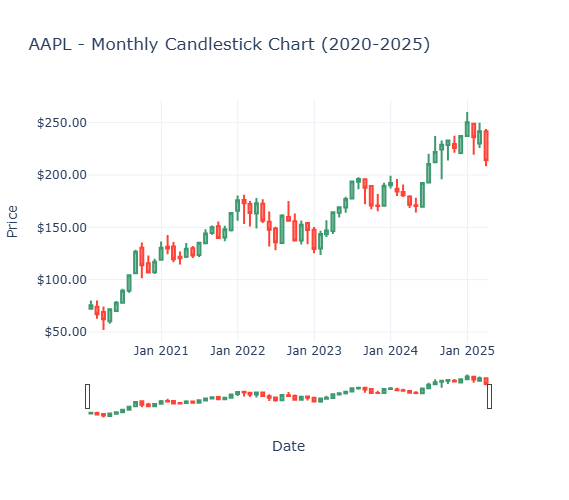

In [30]:
fig = go.Figure(data=[go.Candlestick(x=monthly_aapl['Date'],
                                 open=monthly_aapl['Open'],
                                 high=monthly_aapl['High'],
                                 low=monthly_aapl['Low'],
                                 close=monthly_aapl['Close'],
                                 name='AAPL Monthly')])

fig.update_layout(title='AAPL - Monthly Candlestick Chart (2020-2025)',
              xaxis_title='Date',
              yaxis_title='Price',
              xaxis_rangeslider_visible=True,
              template='plotly_white',
              height=500,
              width=1200,
              yaxis=dict(tickformat='$.2f'),
              xaxis=dict(tickformat='%b %Y'))
fig.show()

In [1]:
#Plot the data
fig = px.histogram(aapl_df,
                x='Daily_Return',
                nbins=100,
                title='AAPL - Daily Returns Distribution',
                labels={'Daily_Return': 'Daily Return (%)'})
fig.show()

NameError: name 'px' is not defined